In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats

In [119]:
#pip install pandas

In [3]:
import pandas as pd

In [4]:
# conversions

def r_int_to_cm(r):
    return r*5.11e12
def m_int_to_g(M):
    return M*2e33
def t_int_to_s(t):
    return t*1e6
def v_int_to_cms(v):
    return v*5.11e6

In [101]:
data = pd.read_csv('2b_output.txt', sep=' ', header=None, names=range(7))
data.columns = ['m','x','y','z','vx','vy','vz']

In [120]:
print(data)

                    m             x             y    z           vx  \
0            2.000000           NaN           NaN  NaN          NaN   
1            0.000002           NaN           NaN  NaN          NaN   
2            1.000000  1.584148e-01  4.286927e-03  0.0  1061.894031   
3      1000000.000000 -1.584148e-07 -4.286927e-09  0.0    -0.001062   
4            2.000000           NaN           NaN  NaN          NaN   
...               ...           ...           ...  ...          ...   
21719  1000000.000000 -1.555391e-07  2.236760e-09  0.0    -0.001167   
21720        2.000000           NaN           NaN  NaN          NaN   
21721        0.000545           NaN           NaN  NaN          NaN   
21722        1.000000  1.574375e-01  2.000551e-03  0.0  1098.150240   
21723  1000000.000000 -1.574375e-07 -2.000551e-09  0.0    -0.001098   

                vy   vz  
0              NaN  NaN  
1              NaN  NaN  
2      2526.424222  0.0  
3        -0.002526  0.0  
4              Na

In [111]:
time_rows = data[data.index % 4 -1 == 0]
times = (time_rows['m'])

m1_rows = data[data.index % 4 -2 == 0]
m2_rows = data[data.index % 4 -3 == 0]

Text(0, 0.5, 'y [IU]')

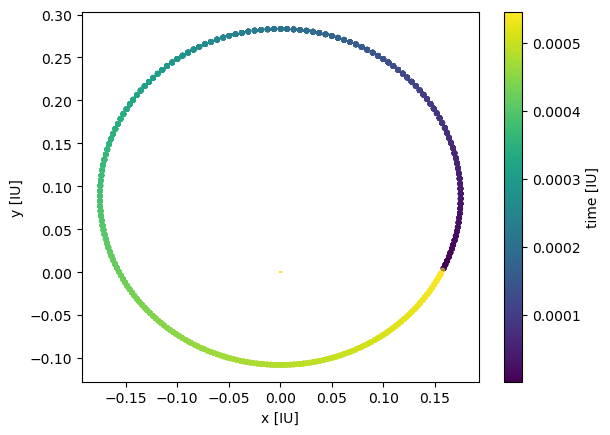

In [118]:
color = times
plt.scatter(m1_rows['x'],m1_rows['y'], c=color,  marker='.', alpha=0.5)
plt.scatter(m2_rows['x'],m2_rows['y'], c=color, s=0.1, alpha=1)
#plt.xlim(-0.2,0.3)
#plt.ylim(-0.2,0.3)
plt.colorbar(label='time [IU]')
plt.xlabel('x [IU]')
plt.ylabel('y [IU]')


Text(0, 0.5, 'y [cm]')

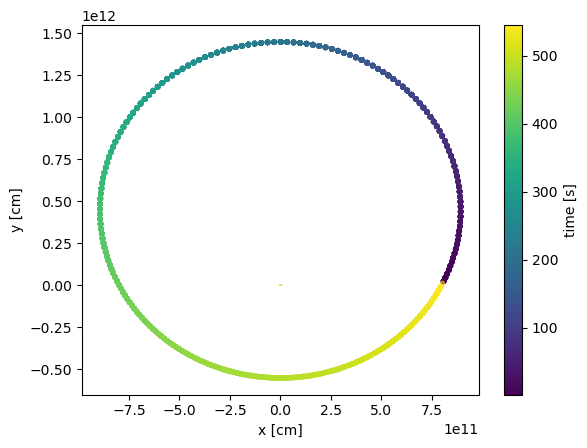

In [121]:
color = t_int_to_s(times)
plt.scatter(r_int_to_cm(m1_rows['x']),r_int_to_cm(m1_rows['y']), c=color,  marker='.', alpha=0.5)
plt.scatter(r_int_to_cm(m2_rows['x']),r_int_to_cm(m2_rows['y']), c=color, s=0.1, alpha=1)
#plt.xlim(-0.2,0.3)
#plt.ylim(-0.2,0.3)
plt.colorbar(label='time [s]')
plt.xlabel('x [cm]')
plt.ylabel('y [cm]')

In [ ]:
# comparison with analytical solution

In [122]:
x1 = np.array(m1_rows['x'])
x2 = np.array(m2_rows['x'])
y1 = np.array(m1_rows['y'])
y2 = np.array(m2_rows['y'])
aper = min(np.sqrt((x1-x2)**2+(y1-y2)**2))
aapo = max(np.sqrt((x1-x2)**2+(y1-y2)**2))

print(aper, aapo)

0.10817743910715849 0.2832114917793005


In [125]:
print('e =',(-aper+aapo)/(aper+aapo))

e = 0.44721257771829775
